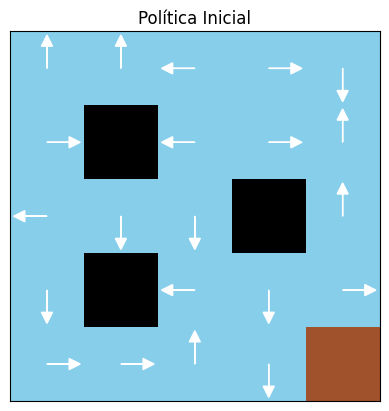

Iteración 1: Delta = 1.0
[-1. -1. -1. -1. -1.]
[-1.  0. -1. -1. -1.]
[-1. -1. -1.  0. -1.]
[-1.  0. -1. -1. -1.]
[-1. -1. -1. -1.  0.]
Iteración 2: Delta = 0.8999999999999999
[-1.9 -1.9 -1.9 -1.9 -1.9]
[-1.9  0.  -1.9 -1.9 -1.9]
[-1.9 -1.9 -1.9  0.  -1.9]
[-1.9  0.  -1.9 -1.9 -1. ]
[-1.9 -1.9 -1.9 -1.   0. ]
Iteración 3: Delta = 0.81
[-2.71 -2.71 -2.71 -2.71 -2.71]
[-2.71  0.   -2.71 -2.71 -2.71]
[-2.71 -2.71 -2.71  0.   -1.9 ]
[-2.71  0.   -2.71 -1.9  -1.  ]
[-2.71 -2.71 -1.9  -1.    0.  ]
Iteración 4: Delta = 0.7290000000000001
[-3.439 -3.439 -3.439 -3.439 -3.439]
[-3.439  0.    -3.439 -3.439 -2.71 ]
[-3.439 -3.439 -3.439  0.    -1.9  ]
[-3.439  0.    -2.71  -1.9   -1.   ]
[-3.439 -2.71  -1.9   -1.     0.   ]
Iteración 5: Delta = 0.6561000000000003
[-4.0951 -4.0951 -4.0951 -4.0951 -3.439 ]
[-4.0951  0.     -4.0951 -3.439  -2.71  ]
[-4.0951 -4.0951 -3.439   0.     -1.9   ]
[-4.0951  0.     -2.71   -1.9    -1.    ]
[-3.439 -2.71  -1.9   -1.     0.   ]
Iteración 6: Delta = 0.59049
[-4.6

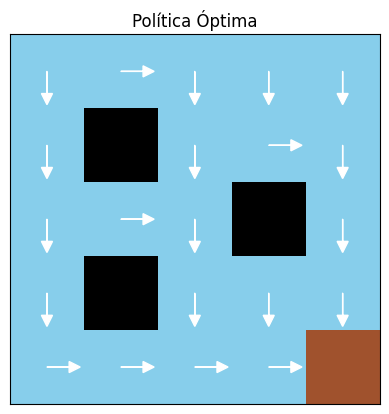


Política Óptima:
(0, 0): Sur  (0, 1): Este  (0, 2): Sur  (0, 3): Sur  (0, 4): Sur  
(1, 0): Sur  (1, 1): Roca  (1, 2): Sur  (1, 3): Este  (1, 4): Sur  
(2, 0): Sur  (2, 1): Este  (2, 2): Sur  (2, 3): Roca  (2, 4): Sur  
(3, 0): Sur  (3, 1): Roca  (3, 2): Sur  (3, 3): Sur  (3, 4): Sur  
(4, 0): Este  (4, 1): Este  (4, 2): Este  (4, 3): Este  (4, 4): Muelle  


In [ ]:
# -*- coding: utf-8 -*-
"""barco_en_oceano.ipynb

Automatically generated by Colab.


"""

# =====================================================================
# Algoritmo de Iteración de Valor
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

"""

Navegación de un barco en un oceano de 5x5
 _________
|_|_|_|_|_|
|_|■|_|_|_|
|_|_|_|■|_|
|_|■|_|_|_|
|_|_|_|_|□|<--Muelle en (4,4)

■ rocas o islotes
□ muelle (destino)

"""


# definición del Entorno
LADO_OCEANO = 5  # Tamaño del oceano (cuadrado de 5x5)
MUELLE = (4, 4)  # Coordenadas del muelle (fila, columna)
ROCAS = [(1, 1), (2, 3), (3, 1)]  # Coordenadas de las rocas
ACCIONES = ["Norte", "Sur", "Este", "Oeste"]
RECOMPENSA_MOVIMIENTO = -1
RECOMPENSA_MUELLE = 0
RECOMPENSA_ROCA = -100
FACTOR_DESCUENTO = 0.9
TOLERANCIA = 1e-6


def es_valido(fila, columna):
    """Verifica si una celda está dentro de los límites del oceano."""
    return 0 <= fila < LADO_OCEANO and 0 <= columna < LADO_OCEANO


def es_roca(fila, columna):
    """Verifica si una celda contiene una roca."""
    return (fila, columna) in ROCAS


def transicion(fila, columna, accion):
    """Determina el siguiente estado (celda) dado el estado actual y la acción."""
    if (fila, columna) == MUELLE:
        return MUELLE  # si ya está en el muelle, se queda ahí

    if accion == "Norte":
        nueva_fila, nueva_columna = fila - 1, columna
    elif accion == "Sur":
        nueva_fila, nueva_columna = fila + 1, columna
    elif accion == "Este":
        nueva_fila, nueva_columna = fila, columna + 1
    elif accion == "Oeste":
        nueva_fila, nueva_columna = fila, columna - 1
    else:
        raise ValueError("Acción inválida")

    if not es_valido(nueva_fila, nueva_columna) or es_roca(nueva_fila, nueva_columna):
        return (
            fila,
            columna,
        )  # permanece en la misma celda si el movimiento no es válido

    return nueva_fila, nueva_columna


def recompensa(fila, columna, accion):
    """Retorna la recompensa para un estado (celda) y acción dados."""
    if (fila, columna) == MUELLE:
        return RECOMPENSA_MUELLE
    nueva_fila, nueva_columna = transicion(fila, columna, accion)
    if es_roca(nueva_fila, nueva_columna):
        return RECOMPENSA_ROCA  # penalizacion por intentar ir a una roca
    return RECOMPENSA_MOVIMIENTO


def dibujar_entorno(politica, titulo):
    """Dibuja el entorno del oceano con las rocas, el muelle y las acciones."""
    mapa = np.zeros((LADO_OCEANO, LADO_OCEANO))  # 0: agua, 1: roca, 2: muelle
    for fila, columna in ROCAS:
        mapa[fila, columna] = 1
    mapa[MUELLE] = 2

    # colores personalizados
    cmap = ListedColormap(["skyblue", "black", "sienna"])
    plt.imshow(mapa, cmap=cmap, origin="lower")

    # inversion del eje para que coincida con las coordenadas de la matriz
    plt.gca().invert_yaxis()

    # agrega las flechas de la politica
    for fila in range(LADO_OCEANO):
        for columna in range(LADO_OCEANO):
            if (fila, columna) not in ROCAS and (fila, columna) != MUELLE:
                accion = politica[(fila, columna)]
                dx, dy = 0, 0
                if accion == "Norte":
                    dy = -0.3  # inversion dy para el eje y invertido
                elif accion == "Sur":
                    dy = 0.3  # inversion dy para el eje y invertido
                elif accion == "Este":
                    dx = 0.3
                elif accion == "Oeste":
                    dx = -0.3
                plt.arrow(
                    columna,
                    fila,
                    dx,
                    dy,
                    head_width=0.15,
                    head_length=0.15,
                    fc="white",
                    ec="white",
                )  # Flechas más pequeñas

    plt.title(titulo)
    plt.xticks([])
    plt.yticks([])
    # plt.show()
    return plt  # devuelve el objeto plt para guardarlo o mostrarlo más tarde


# inicializacion de la función de valor
funcion_valor = np.zeros((LADO_OCEANO, LADO_OCEANO))
funcion_valor[MUELLE] = 0  # el muelle tiene valor 0

# politica inicial (aleatoria)
politica_inicial = {}
for fila in range(LADO_OCEANO):
    for columna in range(LADO_OCEANO):
        if (fila, columna) not in ROCAS and (fila, columna) != MUELLE:
            politica_inicial[(fila, columna)] = np.random.choice(ACCIONES)
        else:
            politica_inicial[(fila, columna)] = None  # Roca o Muelle

#  entorno con la política inicial
plt_inicial = dibujar_entorno(politica_inicial, "Política Inicial")
plt_inicial.show()  # muestra el grafico inicial

# algoritmo de iteracion de valor
iteracion = 0
while True:
    iteracion += 1
    delta = 0  # para verificar la convergencia

    # copia de la nueva finco de valor v(s)
    funcion_valor_anterior = funcion_valor.copy()

    for fila in range(LADO_OCEANO):
        for columna in range(LADO_OCEANO):
            if es_roca(fila, columna):
                continue  # no se actualizan las rocas
            if (fila, columna) == MUELLE:
                continue  # no actualiza el valor del muelle
            # aqui se calcula el valor de cada celda con la ecuación de Bellman
            valores_acciones = []
            for accion in ACCIONES:
                nueva_fila, nueva_columna = transicion(
                    fila, columna, accion
                )  # transicion me devuelve la nueva posicion de barco (nuevo estado)
                recompensa_inmediata = recompensa(
                    fila, columna, accion
                )  # recompensa devuelve 0: muelle, -1: avance, -100:colision con roca
                valores_acciones.append(
                    recompensa_inmediata
                    + FACTOR_DESCUENTO * funcion_valor[nueva_fila, nueva_columna]
                )  # ecuacion de bellman

            funcion_valor[fila, columna] = max(valores_acciones)
            delta = max(
                delta,
                abs(
                    funcion_valor[fila, columna] - funcion_valor_anterior[fila, columna]
                ),
            )

    print(f"Iteración {iteracion}: Delta = {delta}")
    # impresion poe consola del valor de cada celda en formato matricial
    for i in range(LADO_OCEANO):
        print(funcion_valor[i, :])
    if delta < TOLERANCIA:
        break

# extraccion de la politica optima
politica_optima = {}
for fila in range(LADO_OCEANO):
    for columna in range(LADO_OCEANO):
        if es_roca(fila, columna):
            politica_optima[(fila, columna)] = "Roca"  # las rocas no tienen política
            continue
        if (fila, columna) == MUELLE:
            politica_optima[(fila, columna)] = "Muelle"
            continue
        # calculo del valor de cada acción para encontrar la mejor
        valores_acciones = []
        for accion in ACCIONES:
            nueva_fila, nueva_columna = transicion(fila, columna, accion)
            recompensa_inmediata = recompensa(fila, columna, accion)
            valores_acciones.append(
                recompensa_inmediata
                + FACTOR_DESCUENTO * funcion_valor[nueva_fila, nueva_columna]
            )

        mejor_accion_indice = np.argmax(valores_acciones)
        politica_optima[(fila, columna)] = ACCIONES[mejor_accion_indice]

# grafico del entorno con la politica óptima
plt_optima = dibujar_entorno(politica_optima, "Política Óptima")
plt_optima.show()  # muestra el gráfico final

# impresion por consola de la poltica optima
print("\nPolítica Óptima:")
for fila in range(LADO_OCEANO):
    for columna in range(LADO_OCEANO):
        print(f"({fila}, {columna}): {politica_optima[(fila, columna)]}", end="  ")
    print()